In [1]:
import pandas as pd
import xarray as xr
import xcdat as xc
import numpy as np
import os
import glob
import re
import cftime
import calendar

/global/homes/j/jungchoi/.conda/envs/pcmdi_metrics/lib/python3.10/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Model information, Target lead time

In [2]:
print("%%%%%%%% start %%%%%%%")
output_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
output_grid = xc.regridder.grid.create_uniform_grid(-88.75, 88.75, 2.5, 0.0, 357.5, 2.5)
output_grid_no = "144x72"

input_dir = "/pscratch/sd/j/jungchoi/OBS"

climatology_year_start = 1981
climatology_year_end = 2010

clim_years = list(range(climatology_year_start, climatology_year_end + 1))
print(clim_years)

%%%%%%%% start %%%%%%%
[1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010]


# Target leadtime average, Horizonal interpolarion for each ensemble members and initializations

In [3]:
data_name = "ERA5"
#obs_var_name = "t2m"
#out_var_name = "tas"
#obs_var_name = "MSL"
#out_var_name = "psl"

#data_name = "GPCP"
#obs_var_name = "precip"
#out_var_name = "pr"

data_name = "HadISST"
obs_var_name = "sic"
out_var_name = "siconc"

output_grid_no = "144x72"

if out_var_name != "siconc":
    each_ds = []
        
    for year in clim_years:   
        if obs_var_name == "t2m" or obs_var_name == "precip":
            file = os.path.join(input_dir, data_name, f"{obs_var_name}.{year}.{output_grid_no}.nc")
            ds = xr.open_dataset(file)                   
    
        if obs_var_name == "MSL":
            file_list = os.path.join(input_dir, data_name, f"{obs_var_name}.{year}*.nc")
            ds = xr.open_mfdataset(file_list,combine='by_coords')
            #print(ds) 
     
        each_ds.append(ds)    
        ds.close()
    all_ds = xr.concat(each_ds, dim="time")
    print(all_ds.time)

elif out_var_name == "siconc":
    file = os.path.join(input_dir, data_name, "HadISST_ice.nc")
    ds = xr.open_dataset(file) 
    all_ds0 = ds.sel(time=ds.time.dt.year.isin(clim_years))
    all_ds = all_ds0.sortby('latitude')
    output_grid_no = "360x180"
    ds.close()

monthly_climatology = all_ds.groupby('time.month').mean(dim='time')
monthly_climatology = monthly_climatology.rename({obs_var_name: out_var_name})

if out_var_name == "psl":
    monthly_climatology = monthly_climatology.regridder.horizontal(f"{out_var_name}", output_grid, tool="regrid2")
    monthly_climatology = monthly_climatology * 0.01    
    
print(monthly_climatology)
print(monthly_climatology.values)
    
# Save to NetCDF for each lead time
output_filename = f"{output_dir}/OBS/{out_var_name}.{output_grid_no}.mon_clim{climatology_year_start}-{climatology_year_end}.nc"
if os.path.exists(output_filename):
    os.remove(output_filename)
monthly_climatology.to_netcdf(output_filename)
print(f"%% OBS monthly climatology dataset saved: {output_filename}")

<xarray.Dataset> Size: 3MB
Dimensions:    (month: 12, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * latitude   (latitude) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nv
Data variables:
    time_bnds  (month, nv) float32 96B 4.584e+04 4.587e+04 ... 4.62e+04
    siconc     (month, latitude, longitude) float32 3MB nan nan ... 0.997 0.997
Attributes:
    Title:                      Monthly version of HadISST sea ice component
    description:                HadISST sea ice concentration.
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    3/3/2025 converted to netcdf from pp format
    supplementary_information:  Upd

2025-06-09 16:58:29,510 [INFO]: category.py(update:224) >> Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-09 16:58:29,510 [INFO]: category.py(update:224) >> Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-09 16:58:29,535 [INFO]: category.py(update:224) >> Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-09 16:58:29,535 [INFO]: category.py(update:224) >> Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


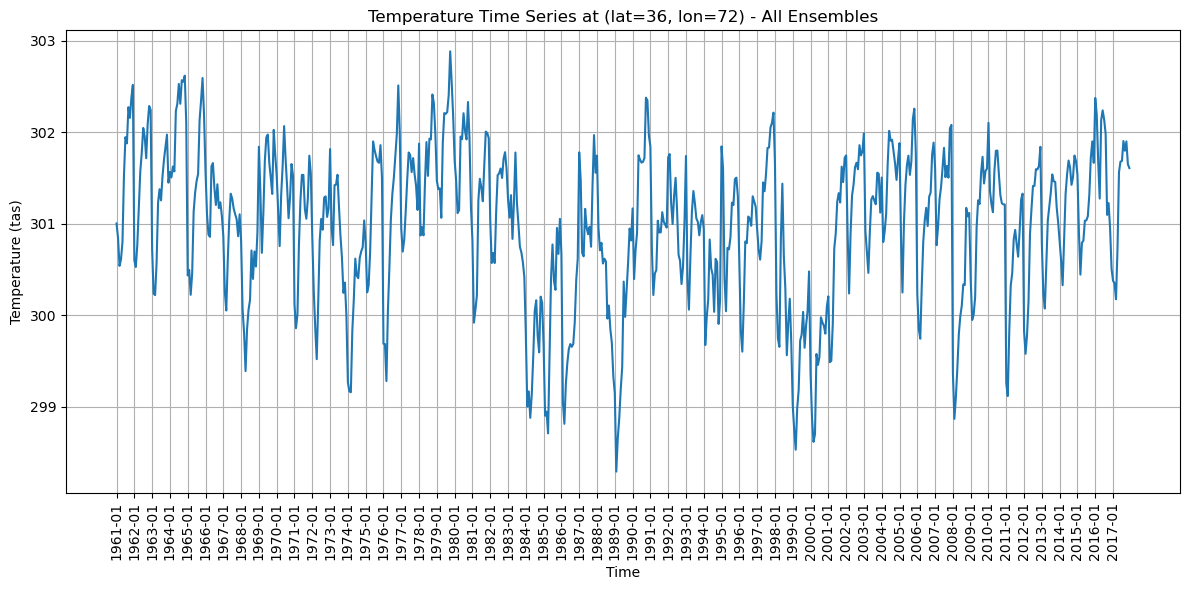

In [51]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


time_str = [str(t) for t in all_ensemble_ds.time.values]
time_str_ym = [ts[:7] for ts in time_str]
#time_array = all_ensemble_ds.time.values
#conv_time = pd.to_datetime(time_array)
#mpl_dates = mdates.date2num(time_array)

n_ens = all_ensemble_ds.sizes["ensemble"]  # 또는 n_ens = all_ensemble_ds.ensemble.size

plt.figure(figsize=(12, 6))
#print(time)
#conv_time = [t.datetime for t in time_list]

#for ens in range(0, 1):
tas_series = all_ensemble_ds.tas[0, :, 36, 72].values
plt.plot(time_str_ym, tas_series, label=f"Ens")

x_pos = np.arange(len(time_str_ym))
step = 12
plt.xticks(ticks=x_pos[::step], labels=np.array(time_str_ym)[::step], rotation=90)

plt.title("Temperature Time Series at (lat=36, lon=72) - All Ensembles")
plt.xlabel("Time")
plt.ylabel("Temperature (tas)")
#plt.legend(ncol=2, fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()


 